# Comparing the two models

This notebook contains a minimal comparison between two in-built models `TaylorT2Ecc` and `TaylorT3Spin` in their common limit (quasicircular, spin-zero).

In [8]:
import matplotlib.pyplot as plt
import numpy as np

from pygwtf.generator import AnalyticTimeFrequencyWaveform
from pygwtf.models import TaylorT2Ecc, TaylorT3Spin

In [2]:
dT = 86400 / 4  # 6 hours
nT = 365 * 4  # 1 year
dt = 5
dF = 1 / dT
nF = int(1 / (2 * dF) / dt) + 1

config = {
    "dT": dT,
    "nT": nT,
    "dt": dt,
    "dF": dF,
    "nF": nF,
    "kernel_width": 100,  # number of frequency bins to use in the fresnel kernel
}

First, let's look at the transverse-traceless polarisations. This is set by passing `tdi_type=None` (the default).

In [3]:
ecc_generator = AnalyticTimeFrequencyWaveform(
    model_class=TaylorT2Ecc,
    config=config,
    tdi_type=None,
)

spin_generator = AnalyticTimeFrequencyWaveform(
    model_class=TaylorT3Spin,
    config=config,
    tdi_type=None,
)

We can generate waveforms by calling the generator.

In [4]:
ecc_generator.model.parameters, spin_generator.model.parameters

(['M', 'eta', 'cosi', 'e0', 'D', 'f0', 'phi_coal'],
 ['M', 'eta', 'cosi', 'D', 'f0', 's1', 's2', 'phi_coal'])

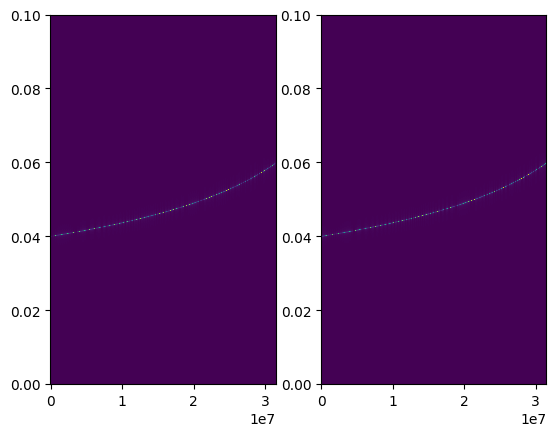

In [5]:
pars = {
    "M": 30,
    "eta": 0.25,
    "cosi": 0.5,
    "e0": 0,
    "D": 1e3,
    "f0": 4e-2,
    "phi_coal": 0.1,
    "s1": 0,
    "s2": 0,
}

tf_ecc = ecc_generator(pars)
tf_spin = spin_generator(pars)

plt.subplot(121)
plt.pcolormesh(
    ecc_generator.t_tranche, ecc_generator.f_tranche, np.abs(tf_ecc[:, :, 0].T)
)
plt.subplot(122)
plt.pcolormesh(
    spin_generator.t_tranche,
    spin_generator.f_tranche,
    np.abs(tf_spin[:, :, 0].T),
)

Mismatch:

In [7]:
(
    1
    - np.abs((tf_ecc.conj() * tf_spin).sum())
    / (tf_ecc.conj() * tf_ecc).real.sum() ** 0.5
    / (tf_spin.conj() * tf_spin).real.sum() ** 0.5
)

np.float64(2.3893438100053288e-05)